# Testing energy metabolism model

Nathaniel Linden (UCSD MAE) - June  2023

In [1]:
import jax
import numpy as np
import jax.numpy as jnp
import equinox as eqx
import diffrax as dfrx
import matplotlib.pyplot as plt
import matplotlib as mpl

# set plot style and import tha

jax.config.update('jax_enable_x64', True)
jax.config.update('jax_platform_name', 'cpu')

### Define the currently used model

***We are using the bibiAK model ***

We define a class for the model.

In [53]:
class metab_model(eqx.Module):
    # metabolic params
    kGly: float
    kHydro: float
    kForAK: float
    kRevAK: float
    VmaxOxPhos: float
    Kadp: float
    n: float

    def __call__(self, t, y, args):
        """Right hand side """
        
        # FLUXES
        # glycolysis
        Jgly = 2*self.kGly*y[1]*y[1]
        # ATP hydrolysis
        Jhydro = self.kHydro*y[2]
        # Adenylate Kinase
        JAK = (self.kForAK*y[2]*y[0]) - (self.kRevAK*y[1]*y[1])
        # Oxidative Phos
        Joxphos = (self.VmaxOxPhos * ((y[1]/self.Kadp)**self.n))/(1 + ((y[1]/self.Kadp)**self.n))

        # now return the odes for each state variable
        dydt = jnp.zeros_like(y)
        dydt = dydt.at[0].set(-JAK) # AMP
        dydt = dydt.at[1].set(-Jgly+2*JAK+Jhydro-Joxphos) # ADP
        dydt = dydt.at[2].set(Jgly-JAK-Jhydro+Joxphos) # ATT

        return dydt
    
class metab_model_bibiAK(eqx.Module):
    # used Bi-Bi rxn kinetics for AK rxn
    # metabolic params
    kGly: float
    kHydro: float
    VforAK: float
    KeqAK: float
    kmm: float
    kmd: float
    kmt: float
    VmaxOxPhos: float
    Kadp: float
    n: float

    def __call__(self, t, y, args):
        """Right hand side """
        
        # FLUXES
        # glycolysis
        Jgly = 2*self.kGly*y[1]*y[1]
        # ATP hydrolysis
        Jhydro = self.kHydro*y[2]
        # Adenylate Kinase
        num_for = (self.VforAK*y[2]*y[0])/(self.kmt*self.kmm)
        den = (1 + (y[2]/self.kmt) + (y[0]/self.kmm) + ((y[2]*y[0])/(self.kmt*self.kmm)) + 
                   ((2*y[1])/self.kmd) + ((y[1]**2)/(self.kmd**2)))
        VrevAK = (self.VforAK*(self.kmd**2))/(self.KeqAK*self.kmt*self.kmm)
        num_rev = (VrevAK*(y[1]**2))/(self.kmd**2)
        JAK = (num_for - num_rev)/den
        # Oxidative Phos
        Joxphos = (self.VmaxOxPhos * ((y[1]/self.Kadp)**self.n))/(1 + ((y[1]/self.Kadp)**self.n))

        # now return the odes for each state variable
        dydt = jnp.zeros_like(y)
        dydt = dydt.at[0].set(-JAK) # AMP
        dydt = dydt.at[1].set(-Jgly+2*JAK+Jhydro-Joxphos) # ADP
        dydt = dydt.at[2].set(Jgly-JAK-Jhydro+Joxphos) # ATT

        return dydt

Define a function to make a "standard" set fo plots.

In [54]:
def plot_adenine_nucleo(sol_basal, sol_stressed, savedir):
    ##### Adenine Nucleotide plots #####
    fig0, ax0 = plt.subplots(1,3, figsize=(16,4))
    names = ['[AMP]', '[ADP]', '[ATP]']
    for i in range(3):
        ax0[i].plot(sol_basal.ts, sol_basal.ys[:,i], 'b', linewidth=2.5)
        ax0[i].plot(sol_basal.ts[-1] + sol_stressed.ts, sol_stressed.ys[:,i], 'k', linewidth=2.5)
        ylims = ax0[i].get_ylim()
        ax0[i].fill_between(np.arange(sol_basal.ts[-1], sol_basal.ts[-1]+sol_stressed.ts[-1]), 
                            ylims[0], ylims[-1], color='grey', alpha=0.5, lw=0)
        # formatting
        ax0[i].set_yscale('log')
        ax0[i].set_title(names[i])
        ax0[i].set_xlabel('time (s)')

        if not i:
            ax0[0].set_ylabel('species concentration (mM)')
        if i == 2:
            ax0[i].set_yscale('linear')
    fig0.savefig(savedir + 'adenine_nucleotide_conc.pdf', bbox_inches='tight')

    ##### Adenine Nucleotide Ratio plots #####
    fig1, ax1 = plt.subplots(1,1, figsize=(4,4))
    ATP_AMP_basal = sol_basal.ys[:,2] / sol_basal.ys[:,0]
    ATP_AMP_stressed = sol_stressed.ys[:,2] / sol_stressed.ys[:,0]
    ATP_ADP_basal = sol_basal.ys[:,2] / sol_basal.ys[:,1]
    ATP_ADP_stressed = sol_stressed.ys[:,2] / sol_stressed.ys[:,1]
    
    ax1.plot(np.hstack((sol_basal.ts, sol_basal.ts[-1]+sol_stressed.ts)), 
             np.hstack((ATP_AMP_basal, ATP_AMP_stressed)), 'b', linewidth=2.5)
    ax1.plot(np.hstack((sol_basal.ts, sol_basal.ts[-1]+sol_stressed.ts)), 
             np.hstack((ATP_ADP_basal, ATP_ADP_stressed)), 'k:', linewidth=2.5)
    ylims = ax1.get_ylim()
    ax1.fill_between(np.arange(sol_basal.ts[-1], sol_basal.ts[-1]+sol_stressed.ts[-1]), 
                            ylims[0], ylims[-1], color='grey', alpha=0.5, lw=0)
    ax1.set_yscale('log')
    ax1.set_ylabel('adenine nucleotide ratio')
    ax1.set_xlabel('time (s)')
    ax1.legend(('ATP:AMP', 'ATP:ADP'))
    fig1.savefig(savedir + 'adenine_nucleotide_ratio.pdf', bbox_inches='tight')

Run a simulation with the *standard* parameters that we have been using

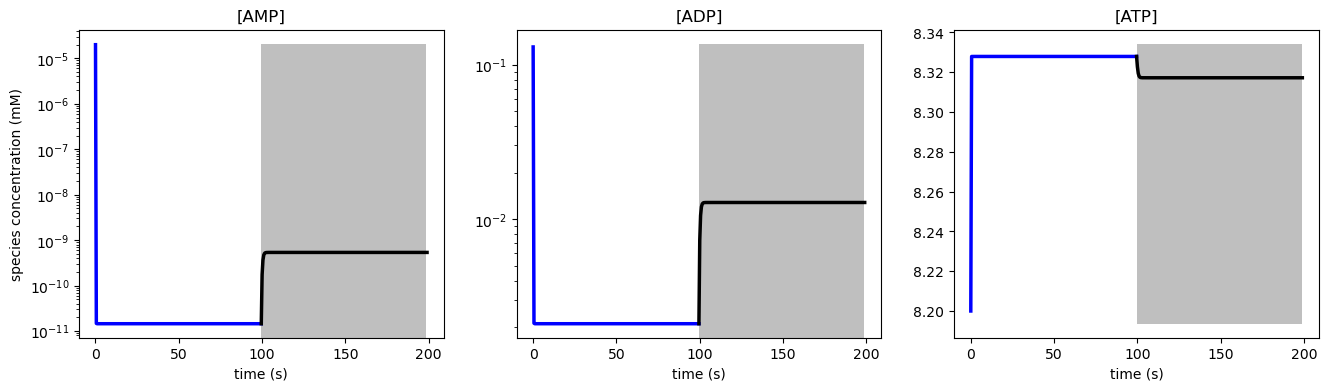

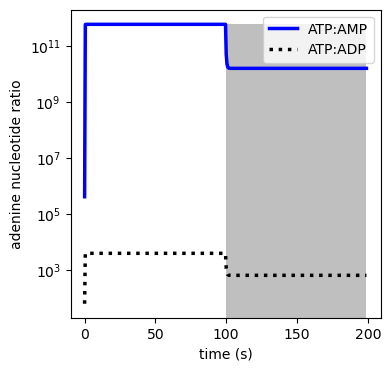

In [80]:
# initial conditions
y0 = np.zeros((3,))
y0[0] = 2e-5   # 'AMP' mM
y0[1] = 1.3e-1 # 'ADP mM
y0[2] = 8.2   # 'ATP mM

# metabolism_params
metab_parms_basal = {'kGly': 1300.0,'kHydro':1.4e-3,'kForAK':40.44,
                     'kRevAK':1.1e-3,'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}
metab_parms_stress = {'kGly': 4.5,'kHydro':1.4e-3,'kForAK':40.44,
                      'kRevAK':1.1e-3,'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}


# Model RHS #
rhs_basal = metab_model(**metab_parms_basal)
rhs_stress = metab_model(**metab_parms_stress)
rhs_basal = dfrx.ODETerm(rhs_basal)
rhs_stress = dfrx.ODETerm(rhs_stress)

# solve
times = jnp.arange(0.0, 100.0, 0.5)
solver=dfrx.Kvaerno5()
stepsize_controller = dfrx.PIDController(rtol=1e-8, atol=1e-8)
t0, t1 = times[0], times[-1]
dt0 = 1e-8 # initial time step
saveat=dfrx.SaveAt(ts=times)

# solve basal
sol_basal = dfrx.diffeqsolve(
    rhs_basal, 
    solver, 
    t0, t1, dt0, 
    y0, 
    saveat=saveat,
    stepsize_controller=stepsize_controller)

# solve stressed
sol_stressed = dfrx.diffeqsolve(
    rhs_stress, 
    solver, 
    t0, t1, dt0, 
    sol_basal.ys[-1,:],
    saveat=saveat, stepsize_controller=stepsize_controller)

# plot
plot_adenine_nucleo(sol_basal, sol_stressed, '../../../figures/metabolism/06022023_model_')

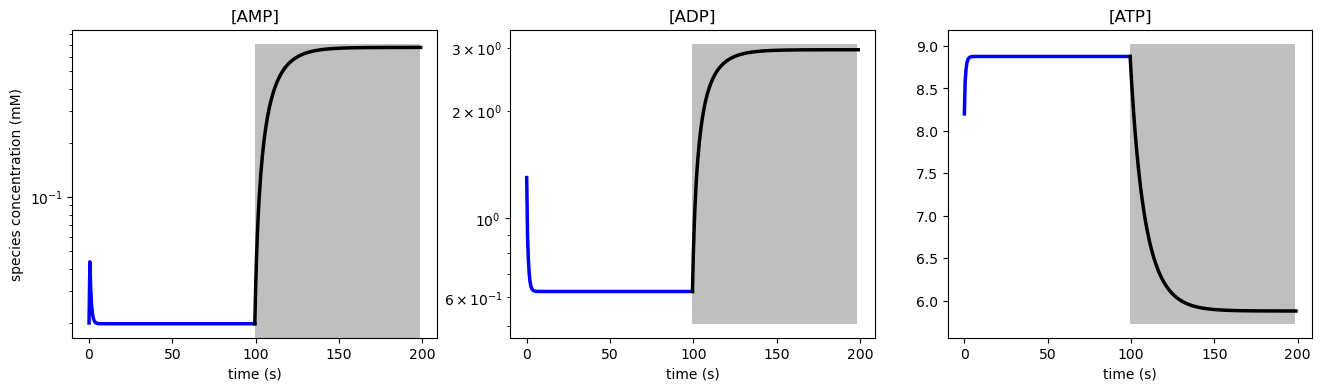

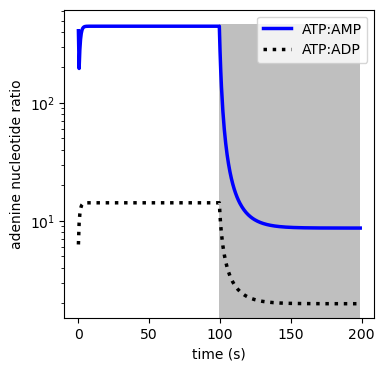

In [81]:
# metabolism_params
# initial conditions
y0 = np.zeros((3,))
y0[0] = 2e-2   # 'AMP' mM
y0[1] = 1.3 # 'ADP mM
y0[2] = 8.2   # 'ATP mM

metab_parms_basal = {'kGly': 0.5,'kHydro':0.1,
                     'VforAK': 14.66, 'KeqAK': 2.21, 'kmm': 0.32, 'kmd': 0.35, 'kmt': 0.27,
                     'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}
metab_parms_stress = {'kGly': 0.005,'kHydro':0.1,
                      'VforAK': 14.66, 'KeqAK': 2.21, 'kmm': 0.32, 'kmd': 0.35, 'kmt': 0.27,
                     'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}

# Model RHS #
rhs_basal = metab_model_bibiAK(**metab_parms_basal)
rhs_stress = metab_model_bibiAK(**metab_parms_stress)
rhs_basal = dfrx.ODETerm(rhs_basal)
rhs_stress = dfrx.ODETerm(rhs_stress)

# solve basal
sol_basal = dfrx.diffeqsolve(
    rhs_basal, 
    solver, 
    t0, t1, dt0, 
    y0, 
    saveat=saveat, max_steps=1000000,
    stepsize_controller=stepsize_controller)

# solve stressed
sol_stressed = dfrx.diffeqsolve(
    rhs_stress, 
    solver, 
    t0, t1, dt0, 
    sol_basal.ys[-1,:], max_steps=1000000,
    saveat=saveat, stepsize_controller=stepsize_controller)

# plot
plot_adenine_nucleo(sol_basal, sol_stressed, '../../../figures/metabolism/bibiAK_model_')